
# 03 EDA — Startup Failure Drivers

## Objective
Use the cleaned dataset to identify distribution patterns, trend shifts, and outlier behavior tied to startup failure risk.

## EDA Structure
1. Portfolio composition and class balance
2. Funding pattern vs closure risk
3. Market and geography risk concentration
4. Temporal trend and lifecycle dynamics
5. Outlier diagnostics for funding features


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)


In [2]:
# Robust project-root detection (works whether notebook runs from repo root or /notebooks)
cwd = Path.cwd().resolve()
if (cwd / 'data' / 'processed' / 'startups_cleaned.csv').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data' / 'processed' / 'startups_cleaned.csv').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError('Could not locate data/processed/startups_cleaned.csv from current working directory')

CLEAN_PATH = PROJECT_ROOT / 'data' / 'processed' / 'startups_cleaned.csv'
df = pd.read_csv(CLEAN_PATH, low_memory=False)

# Datetime standardization
for dcol in ['founded_at', 'first_funding_at', 'last_funding_at']:
    if dcol in df.columns:
        df[dcol] = pd.to_datetime(df[dcol], errors='coerce')

# Ensure core derived fields exist
if 'is_closed' not in df.columns:
    df['is_closed'] = (df['status'].astype(str).str.lower() == 'closed').astype(int)

if 'avg_funding_per_round' not in df.columns:
    df['avg_funding_per_round'] = np.where(
        (df['funding_rounds'] > 0) & (df['funding_total_usd'] > 0),
        df['funding_total_usd'] / df['funding_rounds'],
        np.nan
    )

# Arrow-safe date differences via integer epoch values
first_i8 = pd.to_datetime(df['first_funding_at'], errors='coerce').to_numpy(dtype='datetime64[ns]').astype('int64')
founded_i8 = pd.to_datetime(df['founded_at'], errors='coerce').to_numpy(dtype='datetime64[ns]').astype('int64')
last_i8 = pd.to_datetime(df['last_funding_at'], errors='coerce').to_numpy(dtype='datetime64[ns]').astype('int64')

ns_per_day = 86_400_000_000_000
nat = np.iinfo('int64').min

days_to_first = (first_i8 - founded_i8) / ns_per_day
funding_duration = (last_i8 - first_i8) / ns_per_day

df['days_to_first_funding'] = np.where((first_i8 == nat) | (founded_i8 == nat), np.nan, days_to_first)
if 'funding_duration_days' not in df.columns:
    df['funding_duration_days'] = np.where((last_i8 == nat) | (first_i8 == nat), np.nan, funding_duration)

print(f'Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('Using file:', CLEAN_PATH)

Loaded cleaned dataset: 49,437 rows x 44 columns
Using file: /Users/rashmianand/Desktop/SectionC_G17_WhyStartupsFail/data/processed/startups_cleaned.csv


## 1) Status Distribution and Baseline Failure Rate

,status,count,pct
0,operating,41827,84.61
1,acquired,3692,7.47
2,closed,2603,5.27
3,unknown,1315,2.66


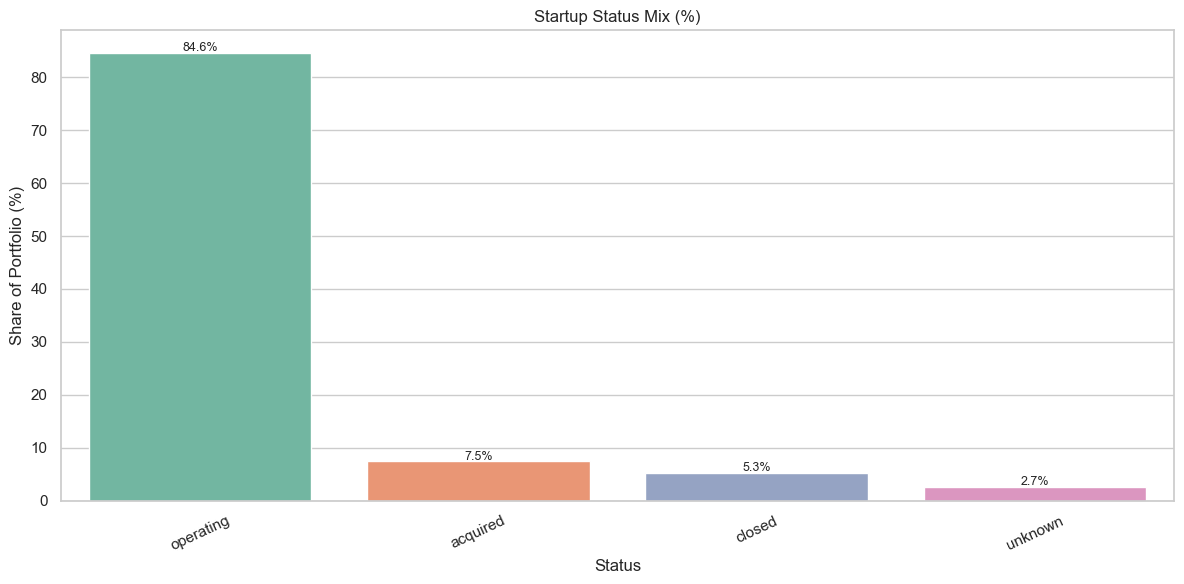

In [3]:

status_summary = (
    df['status']
    .fillna('unknown')
    .value_counts()
    .rename_axis('status')
    .reset_index(name='count')
)
status_summary['pct'] = (status_summary['count'] / len(df) * 100).round(2)

fig, ax = plt.subplots()
sns.barplot(data=status_summary, x='status', y='pct', hue='status', legend=False, ax=ax, palette='Set2')
ax.set_title('Startup Status Mix (%)')
ax.set_ylabel('Share of Portfolio (%)')
ax.set_xlabel('Status')
for i, v in enumerate(status_summary['pct']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=25)
plt.tight_layout()

status_summary


**Insight (Context + Why It Matters)**
- This chart sets the baseline reality of your portfolio: most startups are still `operating`, while `closed` is a smaller share.
- This does **not** mean failure is unimportant. In startup ecosystems, even a smaller closed segment can represent large capital loss and talent loss.
- Real-world example: if an investor backs 100 firms and 10-15 fail, those few failures can still wipe out returns from many average performers.
- Practical meaning for your project: all later analysis should focus on *what increases the probability of entering that closed segment*, not only on raw counts.

## 2) Funding Rounds vs Failure Probability

,funding_rounds,total,failure_rate,failure_rate_pct
0,1.0,32038,0.061974,6.197364
1,2.0,9219,0.048832,4.883204
2,3.0,4025,0.031448,3.144814
3,4.0,1997,0.032192,3.219213
4,5.0,1001,0.023279,2.327935
5,6.0,560,0.016275,1.627486
6,7.0,252,0.024390,2.439024
7,8.0,152,0.061224,6.122449
8,9.0,84,0.012346,1.234568
9,10.0,43,0.000000,0.000000


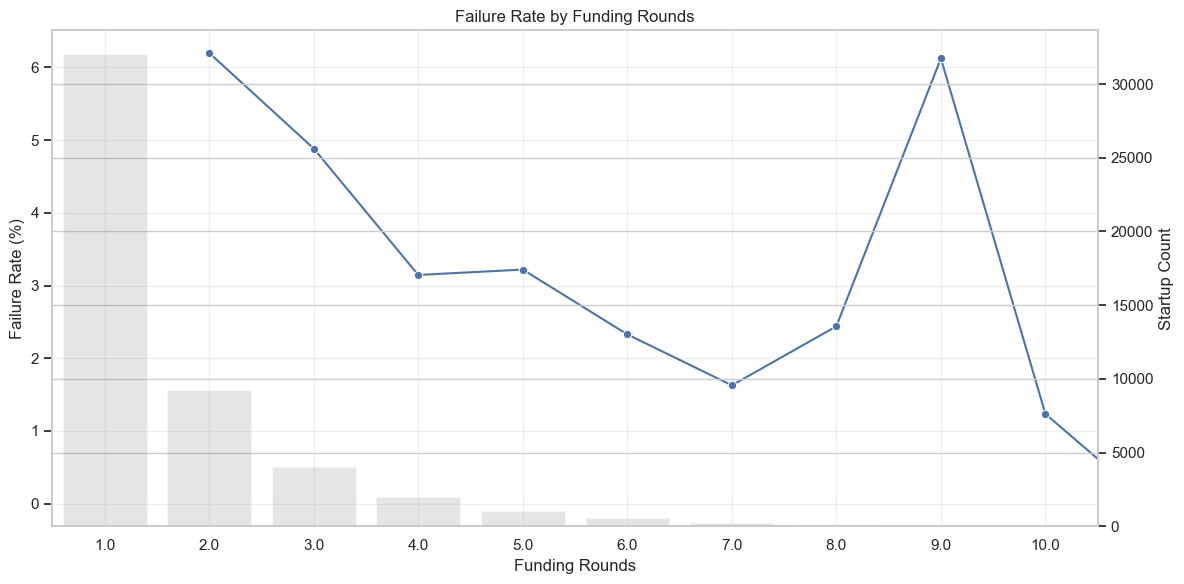

In [4]:

rounds_df = df[(df['funding_rounds'].notna()) & (df['funding_rounds'] >= 0) & (df['funding_rounds'] <= 10)].copy()
closure_by_round = (
    rounds_df.groupby('funding_rounds')
    .agg(total=('is_closed', 'size'), failure_rate=('is_closed', 'mean'))
    .reset_index()
)
closure_by_round['failure_rate_pct'] = closure_by_round['failure_rate'] * 100

fig, ax1 = plt.subplots()
sns.lineplot(data=closure_by_round, x='funding_rounds', y='failure_rate_pct', marker='o', ax=ax1)
ax1.set_title('Failure Rate by Funding Rounds')
ax1.set_xlabel('Funding Rounds')
ax1.set_ylabel('Failure Rate (%)')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
sns.barplot(data=closure_by_round, x='funding_rounds', y='total', alpha=0.20, color='gray', ax=ax2)
ax2.set_ylabel('Startup Count')

plt.tight_layout()
closure_by_round


**Insight (Context + Why It Happens)**
- When failure rate drops as funding rounds increase, it usually reflects two mechanisms.
- Mechanism 1: **selection effect**. Companies that survive long enough to raise multiple rounds are often already stronger in product-market fit, team quality, or revenue traction.
- Mechanism 2: **resource effect**. More rounds provide runway for hiring, marketing, compliance, and pivoting when the first strategy fails.
- Real-world example: two similar startups start with seed money; the one that reaches Series B can absorb a bad quarter, while the one with only seed may shut down faster.
- Important caution: low rounds can be a *signal* of risk, not always the root cause by itself.

## 3) Distribution and Outliers: Total Funding (Log Scale View)

,metric,value
0,funding_records,40905.00
1,iqr_upper_fence,24475000.00
2,outlier_count,5231.00
3,outlier_pct,12.79


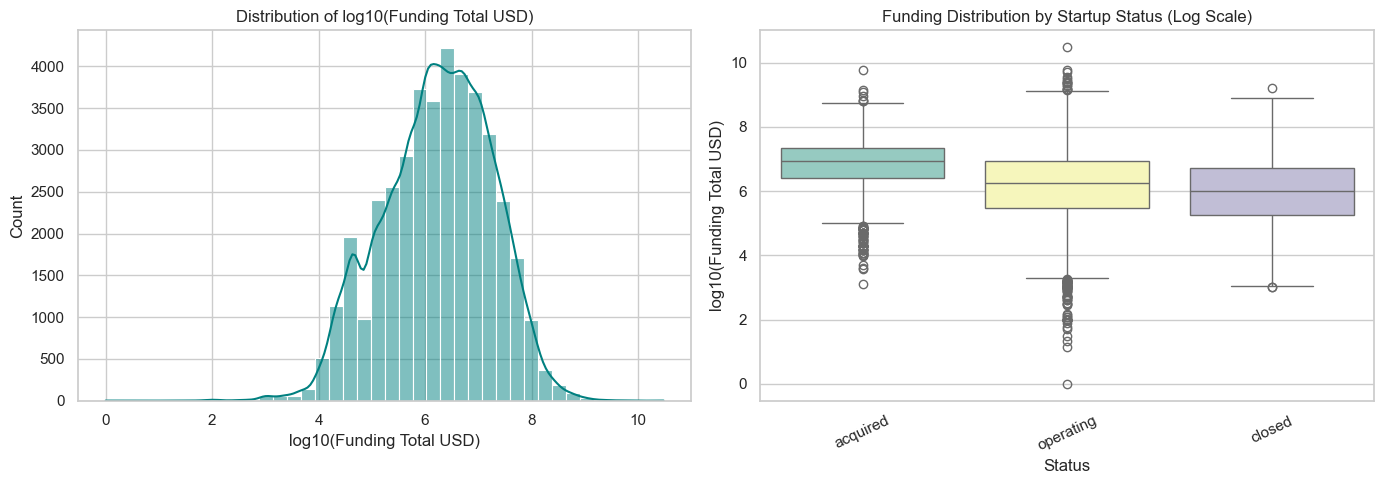

In [5]:

fund_df = df[df['funding_total_usd'] > 0].copy()
fund_df['log_funding'] = np.log10(fund_df['funding_total_usd'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(fund_df['log_funding'], bins=40, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of log10(Funding Total USD)')
axes[0].set_xlabel('log10(Funding Total USD)')

sns.boxplot(data=fund_df, x='status', y='log_funding', hue='status', legend=False, ax=axes[1], palette='Set3')
axes[1].set_title('Funding Distribution by Startup Status (Log Scale)')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('log10(Funding Total USD)')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()

q1, q3 = fund_df['funding_total_usd'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outlier_count = int((fund_df['funding_total_usd'] > upper_fence).sum())
outlier_pct = round(outlier_count / len(fund_df) * 100, 2)

pd.DataFrame({
    'metric': ['funding_records', 'iqr_upper_fence', 'outlier_count', 'outlier_pct'],
    'value': [len(fund_df), upper_fence, outlier_count, outlier_pct]
})


**Insight (Outliers in Startup Funding)**
- The funding distribution is strongly right-skewed: a few companies raise very large amounts while most raise much less.
- This is normal in venture ecosystems and often linked to market size, growth speed, founder network, and investor confidence.
- Real-world example: an AI infrastructure startup with rapid enterprise adoption can raise 10x the capital of a niche B2C product in the same year.
- So these points should not be removed blindly as “noise”; they represent true market behavior and can explain why averages sometimes look misleading.
- Best practice: keep outliers, but use robust statistics (median, log scale, non-parametric tests), which your notebook already does.

## 4) Sector-Level Failure Risk (Minimum Sample Filter)

,market,total,closed,failure_rate_pct
540,Public Relations,173,35.0,20.231214
153,Curated Web,1655,253.0,15.287009
629,Social Network Media,176,24.0,13.636364
732,Web Development,103,13.0,12.621359
461,Networking,189,23.0,12.169312
448,Music,296,36.0,12.162162
421,Messaging,297,34.0,11.447811
622,Social Media,876,96.0,10.958904
277,Games,1182,120.0,10.152284
586,Search,289,28.0,9.688581


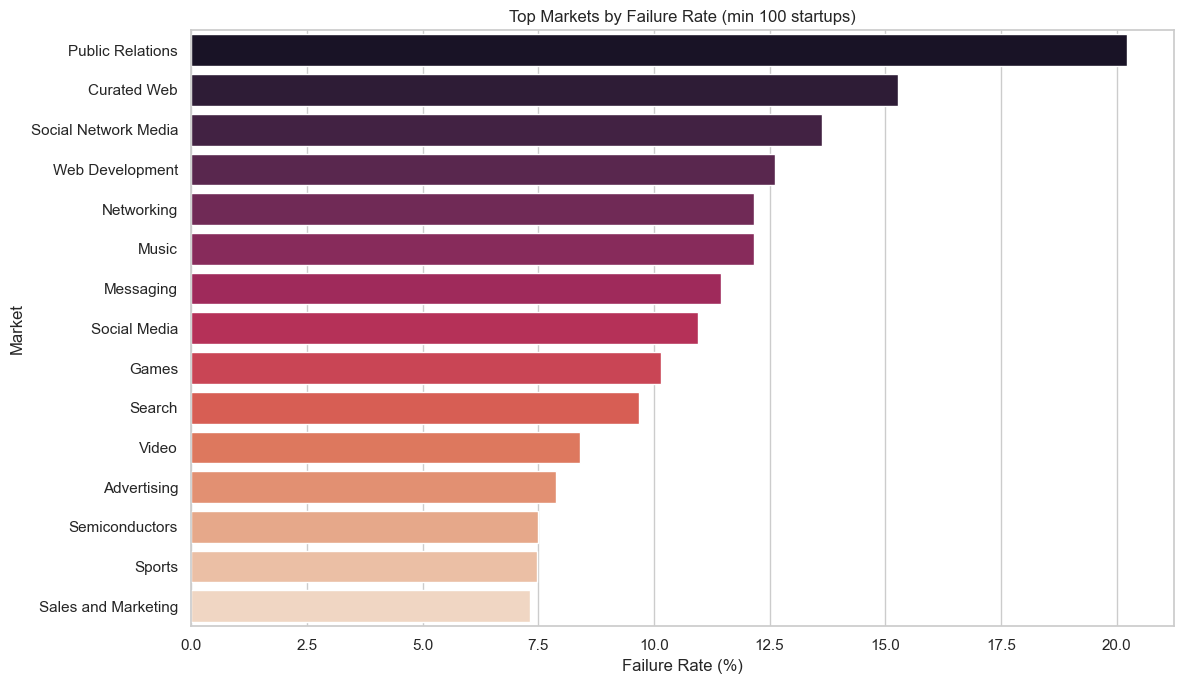

In [6]:

sector = (
    df.groupby('market')
    .agg(total=('is_closed', 'size'), closed=('is_closed', 'sum'))
    .reset_index()
)
sector = sector[sector['total'] >= 100].copy()
sector['failure_rate_pct'] = sector['closed'] / sector['total'] * 100
sector = sector.sort_values('failure_rate_pct', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=sector, x='failure_rate_pct', y='market', hue='market', legend=False, ax=ax, palette='rocket')
ax.set_title('Top Markets by Failure Rate (min 100 startups)')
ax.set_xlabel('Failure Rate (%)')
ax.set_ylabel('Market')
plt.tight_layout()

sector[['market', 'total', 'closed', 'failure_rate_pct']]


**Insight (Sector Risk Is Structural, Not Random)**
- Failure differences by market/sector often come from structural conditions: customer acquisition cost, sales cycle length, regulation pressure, and switching barriers.
- Example pattern: consumer markets can face rapid trend shifts and high churn, while enterprise markets may have slower but stickier demand.
- Real-world example: a gaming startup may scale fast but can collapse if user retention drops after launch; a B2B SaaS startup may grow slower but survive longer with recurring contracts.
- Filtering sectors with minimum sample size is important because it avoids overreacting to unstable percentages from tiny groups.
- Strategic use: this helps founders and investors adjust expectations by sector rather than applying one universal failure benchmark.

## 5) Country-Level Failure Risk (Minimum Sample Filter)

,country_code,total,closed,failure_rate_pct
5,AUT,103,9.0,8.737864
43,HKG,126,9.0,7.142857
50,ISR,682,47.0,6.891496
34,ESP,549,34.0,6.193078
38,GBR,2642,156.0,5.904618
99,SWE,315,18.0,5.714286
93,SGP,299,17.0,5.685619
48,IRL,306,17.0,5.555556
37,FRA,866,47.0,5.427252
2,ARG,149,8.0,5.369128


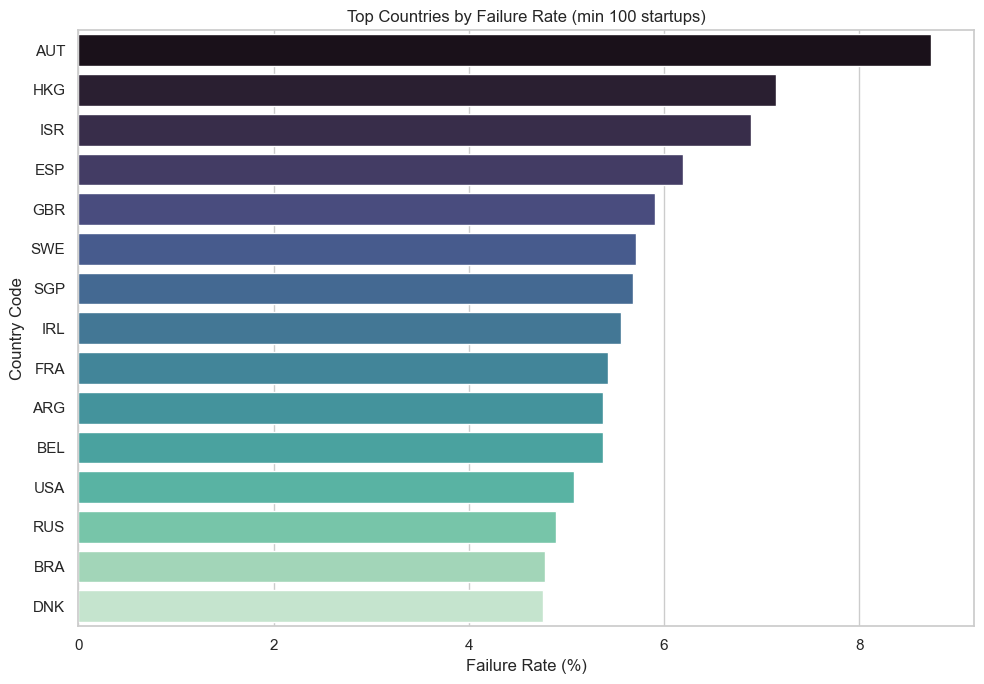

In [7]:

country = (
    df.groupby('country_code')
    .agg(total=('is_closed', 'size'), closed=('is_closed', 'sum'))
    .reset_index()
)
country = country[country['total'] >= 100].copy()
country['failure_rate_pct'] = country['closed'] / country['total'] * 100
country = country.sort_values('failure_rate_pct', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=country, x='failure_rate_pct', y='country_code', hue='country_code', legend=False, ax=ax, palette='mako')
ax.set_title('Top Countries by Failure Rate (min 100 startups)')
ax.set_xlabel('Failure Rate (%)')
ax.set_ylabel('Country Code')
plt.tight_layout()

country[['country_code', 'total', 'closed', 'failure_rate_pct']]


**Insight (Geography and Ecosystem Maturity)**
- Country-level failure gaps usually reflect ecosystem maturity more than founder capability alone.
- Key drivers include access to late-stage capital, strength of local mentorship networks, policy environment, hiring pool, and exit opportunities.
- Real-world example: two startups with similar products may perform differently if one operates in a market with deeper venture networks and easier follow-on funding.
- Interpretation rule: country rates should be treated as context indicators, not as deterministic judgments about startup quality.

## 6) Cohort Trend: Failure Rate by Founding Year

,founded_year,total,closed,failure_rate_pct
15,2005.0,1417,105.0,7.410021
16,2006.0,1807,162.0,8.965136
17,2007.0,2331,241.0,10.338910
18,2008.0,2348,218.0,9.284497
19,2009.0,2979,254.0,8.526351
20,2010.0,3773,289.0,7.659687
21,2011.0,4905,251.0,5.117227
22,2012.0,5211,116.0,2.226060
23,2013.0,4044,27.0,0.667656
24,2014.0,1469,2.0,0.136147


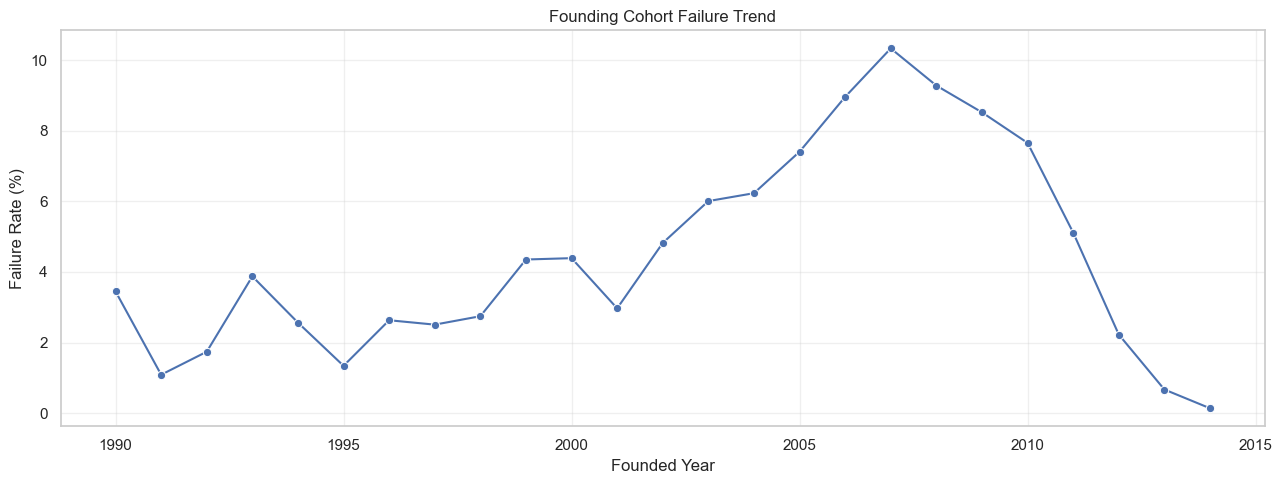

In [8]:

yearly = (
    df[df['founded_year'].between(1990, 2015)]
    .groupby('founded_year')
    .agg(total=('is_closed', 'size'), closed=('is_closed', 'sum'))
    .reset_index()
)
yearly = yearly[yearly['total'] >= 30].copy()
yearly['failure_rate_pct'] = yearly['closed'] / yearly['total'] * 100

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=yearly, x='founded_year', y='failure_rate_pct', marker='o', ax=ax)
ax.set_title('Founding Cohort Failure Trend')
ax.set_xlabel('Founded Year')
ax.set_ylabel('Failure Rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()

yearly.tail(10)


**Insight (Cohort Timing and Macro Cycles)**
- Founding year trends capture macro timing effects: liquidity cycles, technology waves, recession pressure, and investor sentiment.
- Startups founded in overheated periods may raise quickly early on but face higher correction risk later.
- Real-world example: companies launched near a funding boom can scale rapidly, but if capital tightens, weak unit economics are exposed.
- Practical meaning: timing is a risk multiplier, so performance should be interpreted relative to cohort conditions.

## 7) Correlation Heatmap of Core Numerical Features

,is_closed,funding_total_usd,funding_rounds,avg_funding_per_round,days_to_first_funding,funding_duration_days
is_closed,1.000000,-0.010537,-0.049079,-0.013975,-0.050900,-0.007036
funding_total_usd,-0.010537,1.000000,0.105224,0.764951,0.047502,0.012134
funding_rounds,-0.049079,0.105224,1.000000,0.013405,-0.056427,0.077189
avg_funding_per_round,-0.013975,0.764951,0.013405,1.000000,0.114675,0.002991
days_to_first_funding,-0.050900,0.047502,-0.056427,0.114675,1.000000,-0.049852
funding_duration_days,-0.007036,0.012134,0.077189,0.002991,-0.049852,1.000000


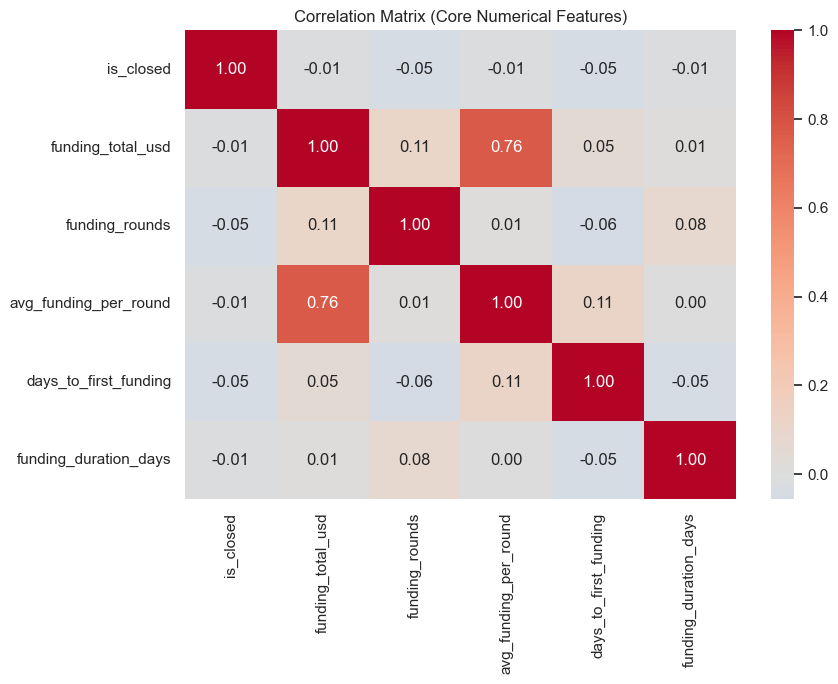

In [9]:

corr_cols = ['is_closed', 'funding_total_usd', 'funding_rounds', 'avg_funding_per_round', 'days_to_first_funding', 'funding_duration_days']
plot_df = df[corr_cols].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)

corr = plot_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0, ax=ax)
ax.set_title('Correlation Matrix (Core Numerical Features)')
plt.tight_layout()

corr


**Insight (Why Correlations Look Small)**
- Weak single-variable correlations are expected in startup failure analysis because failure is multi-causal.
- A startup can fail despite high funding (poor execution), or survive with lower funding (strong efficiency and niche fit).
- Real-world example: one company with large capital burns cash on weak retention; another with smaller capital survives through focused monetization.
- Conclusion: predictive understanding should combine multiple features together, which is exactly why Notebook 04 uses multivariate statistical modeling.


## EDA Conclusion
- Failure is multi-factor and not explained by one variable alone.
- Capital access variables, market context, and founding cohort timing jointly shape risk.
- Outliers are present by design in VC data; robust statistical methods are appropriate for the next notebook.
